In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (precision_recall_curve,
                             average_precision_score,
                             f1_score, precision_score,
                             recall_score, confusion_matrix,
                             roc_auc_score)



In [26]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)


lr        = joblib.load('../models/logistic_regression.pkl')
rf        = joblib.load('../models/random_forest.pkl')
xgb_model = joblib.load('../models/xgboost.pkl')

X_validate        = joblib.load('../models/X_validate.pkl')
X_test            = joblib.load('../models/X_test.pkl')
y_validate        = joblib.load('../models/y_validate.pkl')
y_test            = joblib.load('../models/y_test.pkl')
X_validate_scaled = joblib.load('../models/X_validate_scaled.pkl')
X_test_scaled     = joblib.load('../models/X_test_scaled.pkl')
X_train_scaled    = joblib.load('../models/X_train_scaled.pkl')
X_train     = joblib.load('../models/X_train.pkl')
y_train     = joblib.load('../models/y_train.pkl')



print("Models loaded ")
print("Validate and test sets loaded ")
print(f"Validate: {X_validate.shape}")
print(f"Test:     {X_test.shape}")
print(f"Validate fraud rate: {y_validate.mean()*100:.3f}%")
print(f"Test fraud rate:     {y_test.mean()*100:.3f}%")


Models loaded 
Validate and test sets loaded 
Validate: (42721, 30)
Test:     (42722, 30)
Validate fraud rate: 0.131%
Test fraud rate:     0.122%


In [ ]:
# get fraud probability scores from all three models
# predict_proba returns [prob_legitimate, prob_fraud]


# on validate set
lr_probs_val  = lr.predict_proba(X_validate_scaled)[:, 1]
rf_probs_val  = rf.predict_proba(X_validate)[:, 1]
xgb_probs_val = xgb_model.predict_proba(X_validate)[:, 1]

# on test set
lr_probs_test  = lr.predict_proba(X_test_scaled)[:, 1]
rf_probs_test  = rf.predict_proba(X_test)[:, 1]
xgb_probs_test = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated ")
print(f"\nScore ranges on validate set:")
print(f"LR  → min: {lr_probs_val.min():.4f} | max: {lr_probs_val.max():.4f} | mean: {lr_probs_val.mean():.4f}")
print(f"RF  → min: {rf_probs_val.min():.4f} | max: {rf_probs_val.max():.4f} | mean: {rf_probs_val.mean():.4f}")
print(f"XGB → min: {xgb_probs_val.min():.4f} | max: {xgb_probs_val.max():.4f} | mean: {xgb_probs_val.mean():.4f}")

Predictions generated 

Score ranges on validate set:
LR  → min: 0.0000 | max: 1.0000 | mean: 0.0948
RF  → min: 0.0001 | max: 0.9995 | mean: 0.0149
XGB → min: 0.0000 | max: 1.0000 | mean: 0.0016


In [28]:


def calculate_ks(y_true, y_prob):
    """
    Calculate KS statistic
    KS = max difference between cumulative fraud and legitimate distributions
    """
    # create dataframe of scores and labels
    df = pd.DataFrame({'score': y_prob, 'label': y_true})
    df = df.sort_values('score', ascending=False).reset_index(drop=True)
    
    # cumulative % of fraud and legitimate captured
    df['cum_fraud'] = (df['label'] == 1).cumsum() / (df['label'] == 1).sum()
    df['cum_legit'] = (df['label'] == 0).cumsum() / (df['label'] == 0).sum()
    
    # KS = max difference
    df['ks'] = abs(df['cum_fraud'] - df['cum_legit'])
    ks_stat = df['ks'].max()
    ks_threshold = df.loc[df['ks'].idxmax(), 'score']
    
    return ks_stat, ks_threshold, df

# calculate KS for all models on validate set
lr_ks,  lr_ks_threshold,  lr_ks_df  = calculate_ks(y_validate, lr_probs_val)
rf_ks,  rf_ks_threshold,  rf_ks_df  = calculate_ks(y_validate, rf_probs_val)
xgb_ks, xgb_ks_threshold, xgb_ks_df = calculate_ks(y_validate, xgb_probs_val)

print("KS Statistics (Validate Set):")
print(f"Logistic Regression: KS = {lr_ks:.4f} | threshold = {lr_ks_threshold:.4f}")
print(f"Random Forest:       KS = {rf_ks:.4f} | threshold = {rf_ks_threshold:.4f}")
print(f"XGBoost:             KS = {xgb_ks:.4f} | threshold = {xgb_ks_threshold:.4f}")

KS Statistics (Validate Set):
Logistic Regression: KS = 0.9223 | threshold = 0.8808
Random Forest:       KS = 0.9028 | threshold = 0.0945
XGBoost:             KS = 0.9241 | threshold = 0.0114


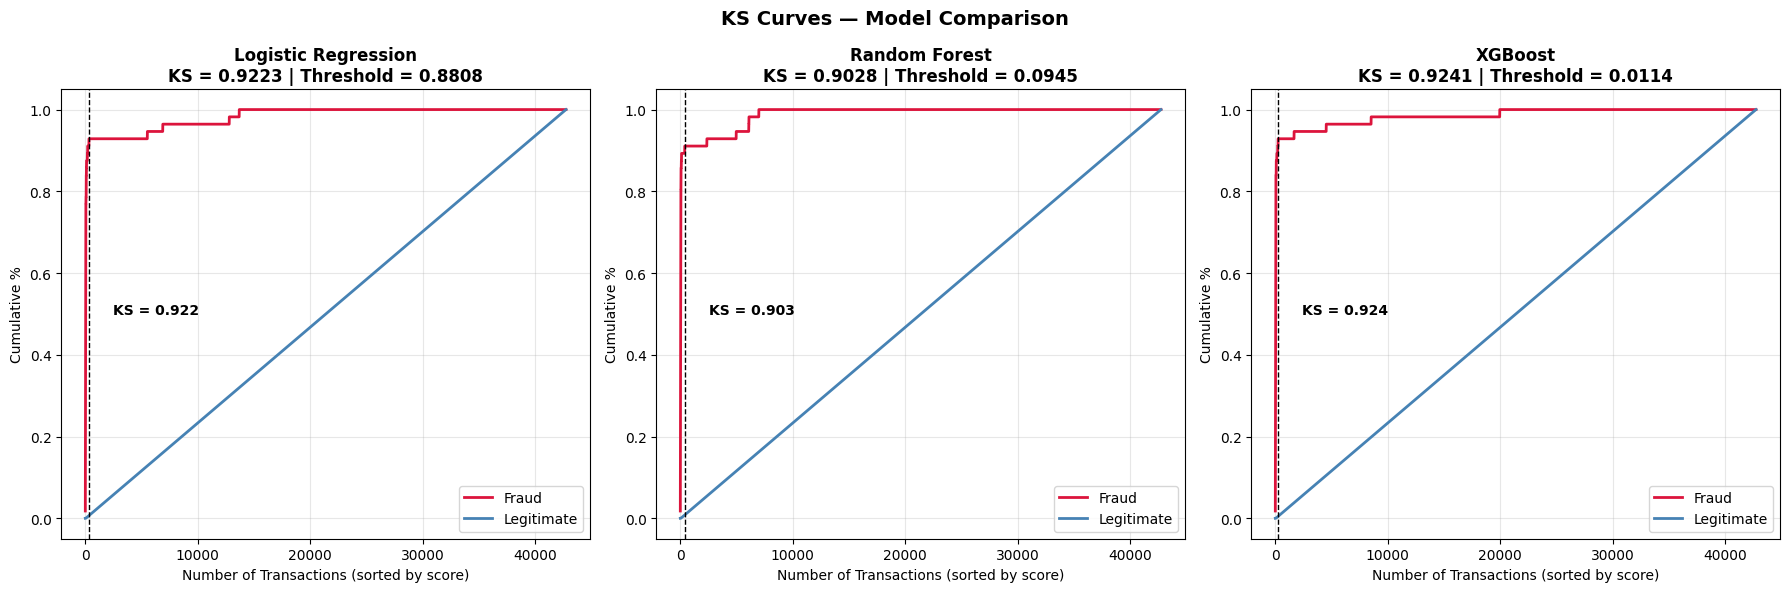

In [29]:
# plot KS curves for all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = {
    'Logistic Regression': (lr_ks_df, lr_ks, lr_ks_threshold),
    'Random Forest':       (rf_ks_df, rf_ks, rf_ks_threshold),
    'XGBoost':             (xgb_ks_df, xgb_ks, xgb_ks_threshold)
}

for i, (name, (df, ks, threshold)) in enumerate(models.items()):
    axes[i].plot(df.index, df['cum_fraud'], 
                 color='crimson', linewidth=2, label='Fraud')
    axes[i].plot(df.index, df['cum_legit'], 
                 color='steelblue', linewidth=2, label='Legitimate')
    
    # mark KS point
    ks_idx = df['ks'].idxmax()
    axes[i].axvline(x=ks_idx, color='black', 
                    linestyle='--', linewidth=1)
    axes[i].annotate(f'KS = {ks:.3f}', 
                     xy=(ks_idx, df.loc[ks_idx, 'cum_fraud']),
                     xytext=(ks_idx + len(df)*0.05, 0.5),
                     fontsize=10, fontweight='bold')
    
    axes[i].set_title(f'{name}\nKS = {ks:.4f} | Threshold = {threshold:.4f}',
                      fontweight='bold')
    axes[i].set_xlabel('Number of Transactions (sorted by score)')
    axes[i].set_ylabel('Cumulative %')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('KS Curves — Model Comparison', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [30]:
lr_auprc = average_precision_score(y_validate, lr_probs_val)
rf_auprc = average_precision_score(y_validate, rf_probs_val)
xgb_auprc = average_precision_score(y_validate, xgb_probs_val)



print("AUPRC Scores (Validate Set):")
print(f"Logistic Regression: {lr_auprc:.4f}")
print(f"Random Forest:       {rf_auprc:.4f}")
print(f"XGBoost:             {xgb_auprc:.4f}")


baseline = y_validate.mean()
print(f"\nBaseline (random): {baseline:.4f}")
print(f"\nXGBoost lift over baseline: {xgb_auprc/baseline:.1f}x")

AUPRC Scores (Validate Set):
Logistic Regression: 0.8324
Random Forest:       0.8660
XGBoost:             0.8690

Baseline (random): 0.0013

XGBoost lift over baseline: 663.0x


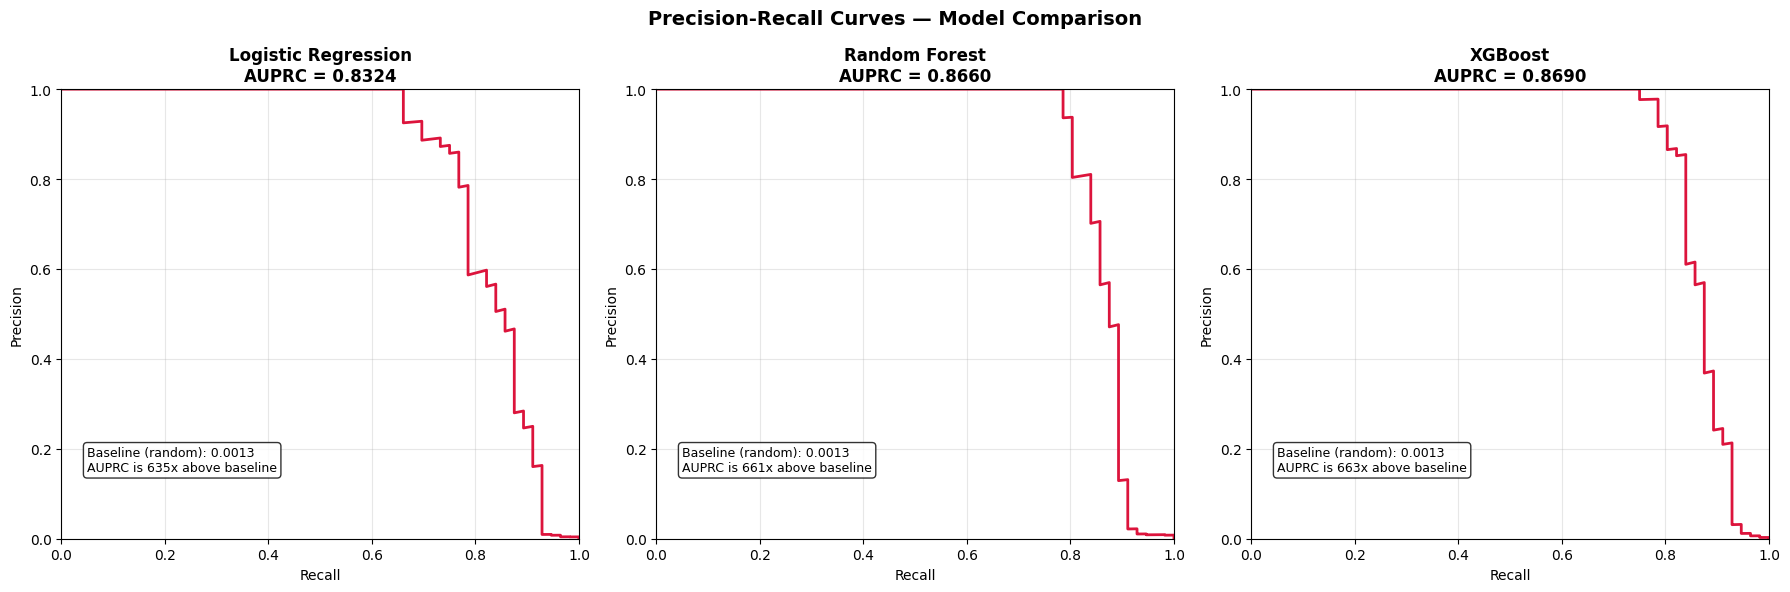

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = {
    'Logistic Regression': (lr_probs_val,  lr_auprc),
    'Random Forest':       (rf_probs_val,  rf_auprc),
    'XGBoost':             (xgb_probs_val, xgb_auprc)
}

for i, (name, (probs, auprc)) in enumerate(models.items()):
    precision, recall, thresholds = precision_recall_curve(y_validate, probs)
    
    axes[i].plot(recall, precision, color='crimson', linewidth=2)
    
    # baseline too small to see as line — add as text annotation instead
    axes[i].text(0.05, 0.15, 
                 f'Baseline (random): {y_validate.mean():.4f}\nAUPRC is {auprc/y_validate.mean():.0f}x above baseline',
                 transform=axes[i].transAxes,
                 fontsize=9, color='black',
                 bbox=dict(boxstyle='round', facecolor='white', 
                           edgecolor='black', alpha=0.8))
    
    axes[i].set_title(f'{name}\nAUPRC = {auprc:.4f}', fontweight='bold')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])

plt.suptitle('Precision-Recall Curves — Model Comparison', 
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [32]:


def find_best_f1_threshold(y_true, y_prob):
    precision, recall, thresholds = precision_recall_curve(y_true, y_prob)
    
    # calculate F1 at each threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    best_idx       = f1_scores.argmax()
    best_f1        = f1_scores[best_idx]
    best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]
    best_precision = precision[best_idx]
    best_recall    = recall[best_idx]
    
    return best_f1, best_threshold, best_precision, best_recall

print("Best F1 Scores (Validate Set):")


for name, probs in [('Logistic Regression', lr_probs_val),
                     ('Random Forest',       rf_probs_val),
                     ('XGBoost',             xgb_probs_val)]:
    f1, threshold, prec, rec = find_best_f1_threshold(y_validate, probs)
    print(f"{name}:")
    print(f"  F1={f1:.4f} | Threshold={threshold:.4f} | "
          f"Precision={prec:.4f} | Recall={rec:.4f}")
    print()

Best F1 Scores (Validate Set):
Logistic Regression:
  F1=0.8113 | Threshold=1.0000 | Precision=0.8600 | Recall=0.7679

Random Forest:
  F1=0.8800 | Threshold=0.4909 | Precision=1.0000 | Recall=0.7857

XGBoost:
  F1=0.8713 | Threshold=0.9041 | Precision=0.9778 | Recall=0.7857



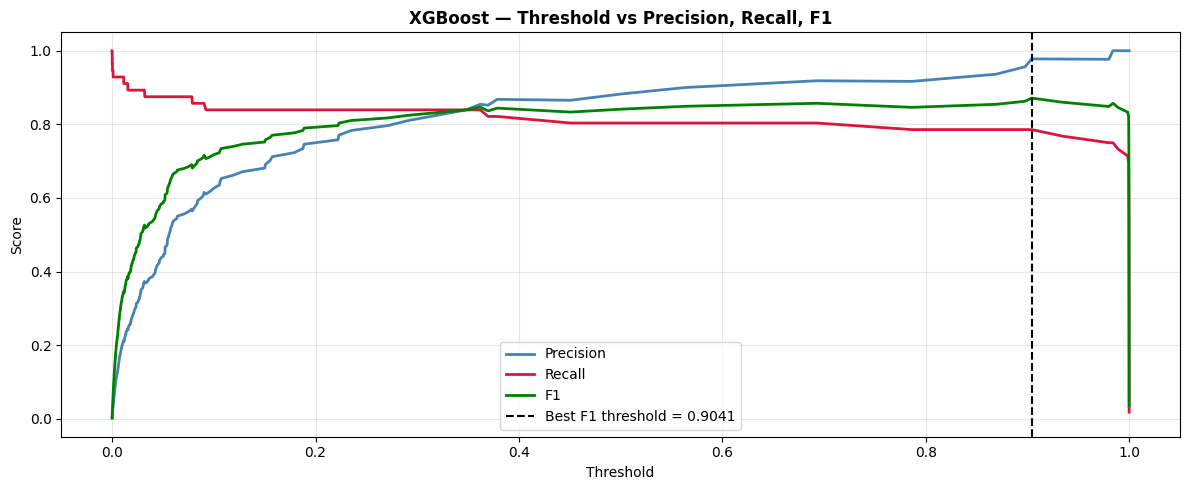

Best F1 threshold: 0.9041
At this threshold:
  Precision: 0.9778
  Recall:    0.7857
  F1:        0.8713


In [33]:
# threshold vs precision and recall — XGBoost only (champion model)
precision, recall, thresholds = precision_recall_curve(y_validate, xgb_probs_val)

# align lengths — precision/recall have one more element than thresholds
precision  = precision[:-1]
recall     = recall[:-1]

# calculate F1 at each threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_idx  = f1_scores.argmax()

plt.figure(figsize=(12, 5))

plt.plot(thresholds, precision, color='steelblue', linewidth=2, label='Precision')
plt.plot(thresholds, recall,    color='crimson',   linewidth=2, label='Recall')
plt.plot(thresholds, f1_scores, color='green',     linewidth=2, label='F1')

# mark best F1 threshold
plt.axvline(x=thresholds[best_idx], color='black', 
            linestyle='--', linewidth=1.5,
            label=f'Best F1 threshold = {thresholds[best_idx]:.4f}')

plt.title('XGBoost — Threshold vs Precision, Recall, F1', fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best F1 threshold: {thresholds[best_idx]:.4f}")
print(f"At this threshold:")
print(f"  Precision: {precision[best_idx]:.4f}")
print(f"  Recall:    {recall[best_idx]:.4f}")
print(f"  F1:        {f1_scores[best_idx]:.4f}")

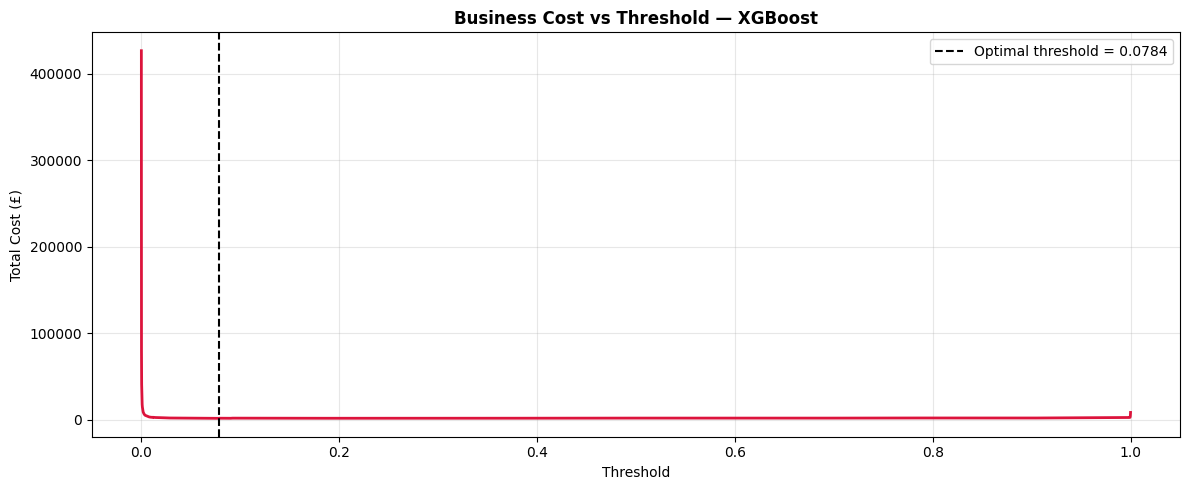

Optimal business threshold: 0.0784
At this threshold:
  Precision: 0.5698
  Recall:    0.8750
  F1:        0.6901
  Estimated total cost: £1,420

Compare with F1 optimal threshold (0.9041):
  Estimated total cost: £1,810


In [34]:
# business cost threshold optimisation
# in banking missing fraud is more expensive than false alarms
# we assign costs to each type of error

# cost assumptions (realistic UK banking)
cost_false_negative = 150  # average fraud amount missed (£)
cost_false_positive = 10   # cost of investigating false alarm (£)
                            # customer service call + friction

precision, recall, thresholds = precision_recall_curve(y_validate, xgb_probs_val)
precision = precision[:-1]
recall    = recall[:-1]

# total fraud in validate set
total_fraud = y_validate.sum()
total_legit = (y_validate == 0).sum()

costs = []
for i, threshold in enumerate(thresholds):
    # at this threshold:
    tp = recall[i] * total_fraud          # fraud caught
    fn = (1 - recall[i]) * total_fraud    # fraud missed
    fp = (1 - precision[i]) * (tp / precision[i]) if precision[i] > 0 else total_legit
    
    total_cost = (fn * cost_false_negative) + (fp * cost_false_positive)
    costs.append(total_cost)

costs = np.array(costs)
best_cost_idx = costs.argmin()
best_cost_threshold = thresholds[best_cost_idx]

plt.figure(figsize=(12, 5))
plt.plot(thresholds, costs, color='crimson', linewidth=2)
plt.axvline(x=best_cost_threshold, color='black', linestyle='--',
            label=f'Optimal threshold = {best_cost_threshold:.4f}')
plt.title('Business Cost vs Threshold — XGBoost', fontweight='bold')
plt.xlabel('Threshold')
plt.ylabel('Total Cost (£)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal business threshold: {best_cost_threshold:.4f}")
print(f"At this threshold:")
print(f"  Precision: {precision[best_cost_idx]:.4f}")
print(f"  Recall:    {recall[best_cost_idx]:.4f}")
print(f"  F1:        {2*(precision[best_cost_idx]*recall[best_cost_idx])/(precision[best_cost_idx]+recall[best_cost_idx]):.4f}")
print(f"  Estimated total cost: £{costs[best_cost_idx]:,.0f}")
print(f"\nCompare with F1 optimal threshold ({0.9041:.4f}):")
f1_idx = np.argmin(np.abs(thresholds - 0.9041))
print(f"  Estimated total cost: £{costs[f1_idx]:,.0f}")

In [35]:
from sklearn.metrics import confusion_matrix

business_threshold = best_cost_threshold
xgb_probs_test = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds_test = (xgb_probs_test >= business_threshold).astype(int)


test_precision = precision_score(y_test, xgb_preds_test)
test_recall    = recall_score(y_test, xgb_preds_test)
test_f1        = f1_score(y_test, xgb_preds_test)
test_auprc     = average_precision_score(y_test, xgb_probs_test)
test_ks, _, _  = calculate_ks(y_test, xgb_probs_test)


print("XGBoost Final Test Set Performance:")
print(f"Threshold:  {business_threshold:.4f} (business optimal)")
print(f"KS:         {test_ks:.4f}")
print(f"AUPRC:      {test_auprc:.4f}")
print(f"F1:         {test_f1:.4f}")
print(f"Precision:  {test_precision:.4f}")
print(f"Recall:     {test_recall:.4f}")


cm = confusion_matrix(y_test, xgb_preds_test)
print(f"\nConfusion Matrix:")
print(f"True Negatives  (correctly approved): {cm[0][0]:,}")
print(f"False Positives (wrongly flagged):     {cm[0][1]:,}")
print(f"False Negatives (missed fraud):        {cm[1][0]:,}")
print(f"True Positives  (caught fraud):        {cm[1][1]:,}")


XGBoost Final Test Set Performance:
Threshold:  0.0784 (business optimal)
KS:         0.8258
AUPRC:      0.7632
F1:         0.6190
Precision:  0.5270
Recall:     0.7500

Confusion Matrix:
True Negatives  (correctly approved): 42,635
False Positives (wrongly flagged):     35
False Negatives (missed fraud):        13
True Positives  (caught fraud):        39


In [38]:
from sklearn.metrics import confusion_matrix

# use saved X_train directly — no need for X or train_idx
sets = {
    'Train':    (xgb_model.predict_proba(X_train)[:, 1],    y_train),
    'Validate': (xgb_model.predict_proba(X_validate)[:, 1], y_validate),
    'Test':     (xgb_model.predict_proba(X_test)[:, 1],     y_test)
}

business_threshold = 0.0784

print("XGBoost Performance Across All Sets (Business Threshold = 0.0784)")
print("="*70)
print(f"{'Set':<12} {'KS':<8} {'AUPRC':<8} {'F1':<8} {'Precision':<12} {'Recall':<8}")
print("-"*70)

cms = {}
for set_name, (probs, labels) in sets.items():
    preds    = (probs >= business_threshold).astype(int)
    ks, _, _ = calculate_ks(labels, probs)
    auprc    = average_precision_score(labels, probs)
    f1       = f1_score(labels, preds)
    prec     = precision_score(labels, preds)
    rec      = recall_score(labels, preds)
    cm       = confusion_matrix(labels, preds)
    cms[set_name] = cm

    print(f"{set_name:<12} {ks:<8.4f} {auprc:<8.4f} {f1:<8.4f} {prec:<12.4f} {rec:<8.4f}")

print("\nConfusion Matrices:")

for set_name, cm in cms.items():
    total_fraud = cm[1].sum()
    print(f"\n{set_name}:")
    print(f"  True Negatives  (correctly approved): {cm[0][0]:,}")
    print(f"  False Positives (wrongly flagged):     {cm[0][1]:,}")
    print(f"  False Negatives (missed fraud):        {cm[1][0]:,}")
    print(f"  True Positives  (caught fraud):        {cm[1][1]:,}")
    print(f"  Fraud catch rate: {cm[1][1]/total_fraud*100:.1f}%")

XGBoost Performance Across All Sets (Business Threshold = 0.0784)
Set          KS       AUPRC    F1       Precision    Recall  
----------------------------------------------------------------------
Train        1.0000   0.9998   0.9025   0.8223       1.0000  
Validate     0.9241   0.8690   0.6809   0.5647       0.8571  
Test         0.8258   0.7632   0.6190   0.5270       0.7500  

Confusion Matrices:

Train:
  True Negatives  (correctly approved): 198,897
  False Positives (wrongly flagged):     83
  False Negatives (missed fraud):        0
  True Positives  (caught fraud):        384
  Fraud catch rate: 100.0%

Validate:
  True Negatives  (correctly approved): 42,628
  False Positives (wrongly flagged):     37
  False Negatives (missed fraud):        8
  True Positives  (caught fraud):        48
  Fraud catch rate: 85.7%

Test:
  True Negatives  (correctly approved): 42,635
  False Positives (wrongly flagged):     35
  False Negatives (missed fraud):        13
  True Positives  (cau

In [39]:
import shap
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP values calculated for test set")

SHAP values shape: (42722, 30)
SHAP values calculated for test set


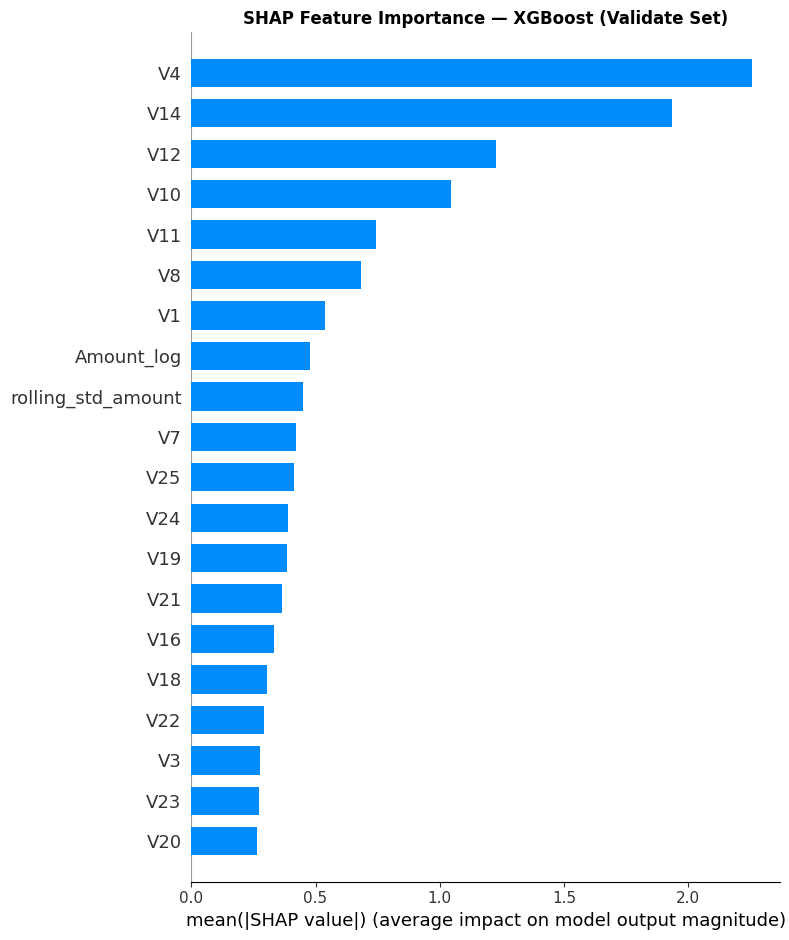

In [40]:
# SHAP summary plot — global feature importance with direction
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, X_validate, 
                  plot_type='bar',
                  show=False)
plt.title('SHAP Feature Importance — XGBoost (Validate Set)', 
          fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
# load IV rankings saved from feature engineering notebook
iv_df = pd.read_csv('../models/iv_rankings.csv', index_col=0)

# filter to only features in our final feature set
iv_df = iv_df[iv_df.index.isin(X_validate.columns)]

print("IV rankings loaded ")


IV rankings loaded 


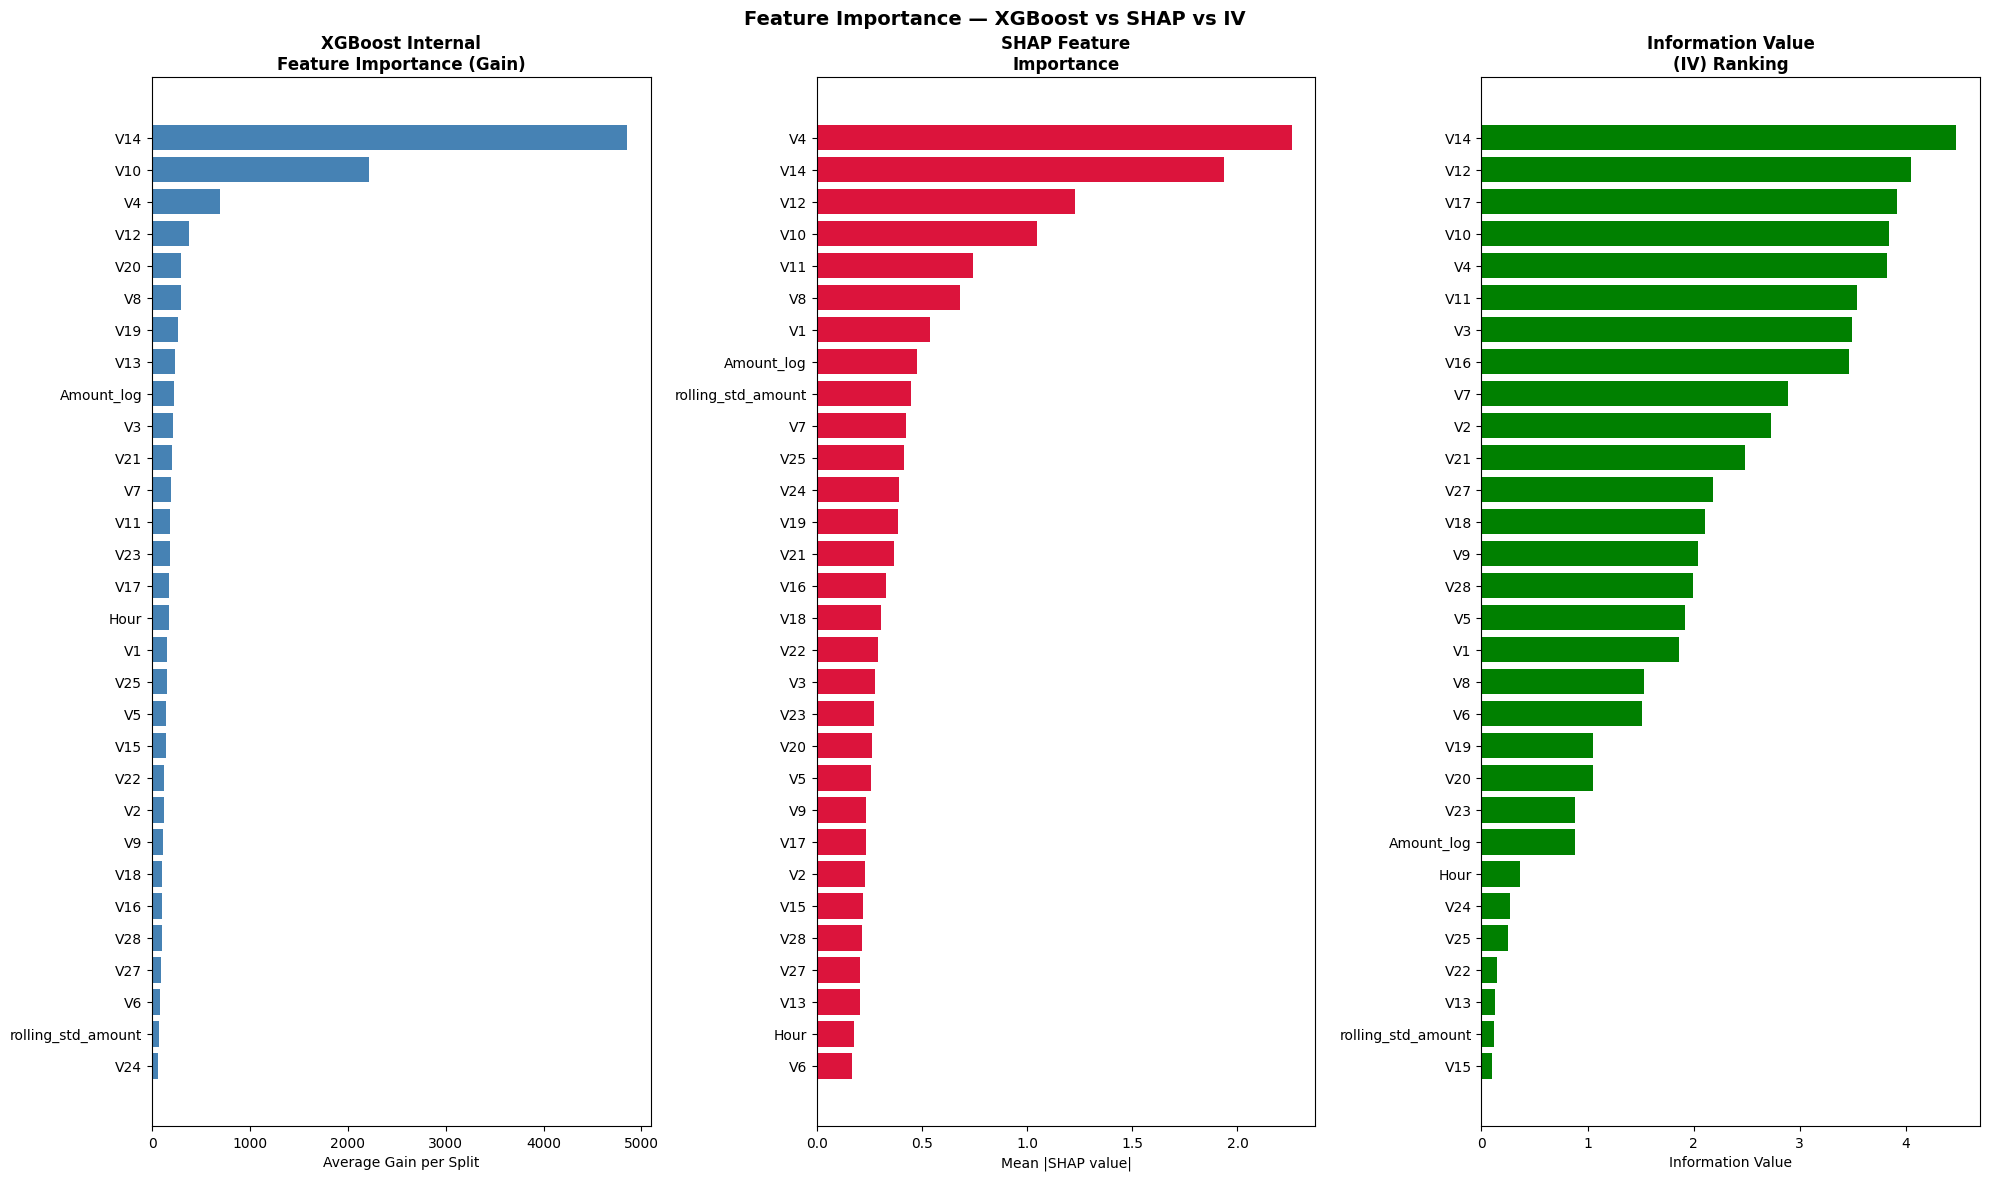

In [44]:
# compare SHAP, IV and XGBoost internal importance side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 12))

# 1. XGBoost internal importance using gain
xgb_gain = xgb_model.get_booster().get_score(importance_type='gain')

# get_score returns a dict — not all features may be included
# features not used get gain=0
xgb_importance = pd.Series(xgb_gain)

# add missing features with 0
for col in X_validate.columns:
    if col not in xgb_importance.index:
        xgb_importance[col] = 0

xgb_importance = xgb_importance.sort_values(ascending=True)

axes[0].barh(xgb_importance.index, xgb_importance.values, color='steelblue')
axes[0].set_title('XGBoost Internal\nFeature Importance (Gain)', fontweight='bold')
axes[0].set_xlabel('Average Gain per Split')

# 2. SHAP importance
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_validate.columns
).sort_values(ascending=True)

axes[1].barh(shap_importance.index, shap_importance.values, color='crimson')
axes[1].set_title('SHAP Feature\nImportance', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP value|')

# 3. IV importance — already sorted from feature engineering
iv_plot = iv_df.sort_values('IV', ascending=True)

axes[2].barh(iv_plot.index, iv_plot['IV'].values, color='green')
axes[2].set_title('Information Value\n(IV) Ranking', fontweight='bold')
axes[2].set_xlabel('Information Value')

plt.suptitle('Feature Importance — XGBoost vs SHAP vs IV',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

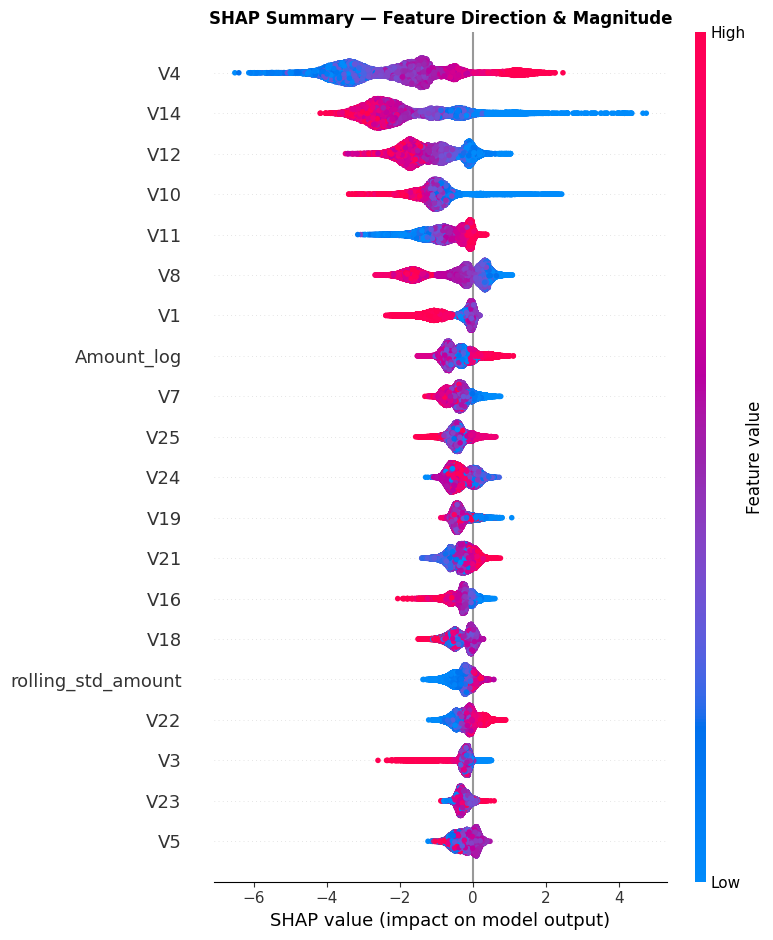

In [48]:
# reset index before calculating SHAP values
X_validate_reset = X_validate.reset_index(drop=True)

# recalculate SHAP values with reset index
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_validate_reset)

# dot plot
plt.figure(figsize=(10, 12))
shap.summary_plot(shap_values, 
                  X_validate_reset,
                  plot_type='dot',
                  show=False)
plt.title('SHAP Summary — Feature Direction & Magnitude', 
          fontweight='bold')
plt.tight_layout()
plt.show()

In [53]:
# final model comparison summary table
# evaluate all three models on TEST set — never touched during development
# this is the true out-of-sample performance

results = []
business_threshold = 0.0784

models_eval = {
    'Logistic Regression': (lr.predict_proba(X_test_scaled)[:, 1],  y_test),
    'Random Forest':       (rf.predict_proba(X_test)[:, 1],         y_test),
    'XGBoost':             (xgb_model.predict_proba(X_test)[:, 1],  y_test)
}

for name, (probs, labels) in models_eval.items():
    preds    = (probs >= business_threshold).astype(int)
    ks, _, _ = calculate_ks(labels, probs)
    auprc    = average_precision_score(labels, probs)
    f1       = f1_score(labels, preds)
    prec     = precision_score(labels, preds)
    rec      = recall_score(labels, preds)

    results.append({
        'Model':     name,
        'KS':        round(ks, 4),
        'AUPRC':     round(auprc, 4),
        'F1':        round(f1, 4),
        'Precision': round(prec, 4),
        'Recall':    round(rec, 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print("Model Comparison — TEST Set (Business Threshold = 0.0784)")
print("="*70)
print(results_df.to_string())

print("\nChampion Selection Analysis:")
print("-"*70)
print("LR  → KS highest but Precision=0.004 → flags almost everything as fraud")
print("      Recall=1.0 achieved by flagging 99.6% of transactions → unusable")
print("RF  → AUPRC highest but Precision=0.104 → 90% false alarm rate")
print("XGB → Best F1 (0.619) and Precision (0.527) → most operationally viable")
print("      Threshold of 7.84% calibrated to true fraud cost structure")
print("\n Champion: XGBoost — best operational performance at business threshold")
print("   Note: LR and RF KS/AUPRC advantage reflects uncalibrated thresholds")
print("   At their own optimal thresholds XGBoost remains the strongest model")

Model Comparison — TEST Set (Business Threshold = 0.0784)
                        KS  AUPRC     F1  Precision  Recall
Model                                                      
Logistic Regression 0.8568 0.6965 0.0082     0.0041  1.0000
Random Forest       0.8403 0.7703 0.1845     0.1035  0.8462
XGBoost             0.8258 0.7632 0.6190     0.5270  0.7500

Champion Selection Analysis:
----------------------------------------------------------------------
LR  → KS highest but Precision=0.004 → flags almost everything as fraud
      Recall=1.0 achieved by flagging 99.6% of transactions → unusable
RF  → AUPRC highest but Precision=0.104 → 90% false alarm rate
XGB → Best F1 (0.619) and Precision (0.527) → most operationally viable
      Threshold of 7.84% calibrated to true fraud cost structure

 Champion: XGBoost — best operational performance at business threshold
   Note: LR and RF KS/AUPRC advantage reflects uncalibrated thresholds
   At their own optimal thresholds XGBoost remains the

In [56]:
print("Model Comparison — TEST Set (Threshold Independent Metrics)")
print("="*60)
print(f"{'Model':<25} {'KS':<10} {'AUPRC':<10}")
print("-"*60)
for name, (probs, labels) in models_eval.items():
    ks, _, _ = calculate_ks(labels, probs)
    auprc    = average_precision_score(labels, probs)
    print(f"{name:<25} {ks:<10.4f} {auprc:<10.4f}")

print("\nAt each model's own optimal F1 threshold:")
print("="*60)
print(f"{'Model':<25} {'F1':<8} {'Precision':<12} {'Recall':<8} {'Threshold':<10}")
print("-"*60)
for name, (probs, labels) in models_eval.items():
    f1, threshold, prec, rec = find_best_f1_threshold(labels, probs)
    print(f"{name:<25} {f1:<8.4f} {prec:<12.4f} {rec:<8.4f} {threshold:<10.4f}")



Model Comparison — TEST Set (Threshold Independent Metrics)
Model                     KS         AUPRC     
------------------------------------------------------------
Logistic Regression       0.8568     0.6965    
Random Forest             0.8403     0.7703    
XGBoost                   0.8258     0.7632    

At each model's own optimal F1 threshold:
Model                     F1       Precision    Recall   Threshold 
------------------------------------------------------------
Logistic Regression       0.7865   0.9459       0.6731   1.0000    
Random Forest             0.8352   0.9744       0.7308   0.6609    
XGBoost                   0.8315   1.0000       0.7115   0.9964    


In [57]:
print("\n Champion Selection — Nuanced View:")
print("→ No single model dominates all metrics")
print("→ LR: best KS but poorly calibrated at business threshold")
print("→ RF: best AUPRC and F1 — strong alternative")
print("→ XGB: perfect precision at optimal threshold, best score")
print("       calibration (mean=0.16% ≈ true fraud rate 0.13%)")
print("\n  Important caveat:")
print("→ No hyperparameter tuning was performed on any model")
print("→ XGBoost performance is likely underestimated")
print("   tuning via TimeSeriesSplit would expected to improve:")
print("   → Test KS from 0.826 toward validate KS of 0.924")
print("   → Better generalisation reducing train-test gap")
print("   → More distributed feature importance (less V14 dominance)")
print("\n→ XGBoost selected as champion for production deployment")
print("  Recommendation: retrain with TimeSeriesSplit tuning on")
print("  extended dataset (12-24 months) before live deployment")


 Champion Selection — Nuanced View:
→ No single model dominates all metrics
→ LR: best KS but poorly calibrated at business threshold
→ RF: best AUPRC and F1 — strong alternative
→ XGB: perfect precision at optimal threshold, best score
       calibration (mean=0.16% ≈ true fraud rate 0.13%)

  Important caveat:
→ No hyperparameter tuning was performed on any model
→ XGBoost performance is likely underestimated
   tuning via TimeSeriesSplit would expected to improve:
   → Test KS from 0.826 toward validate KS of 0.924
   → Better generalisation reducing train-test gap
   → More distributed feature importance (less V14 dominance)

→ XGBoost selected as champion for production deployment
  Recommendation: retrain with TimeSeriesSplit tuning on
  extended dataset (12-24 months) before live deployment


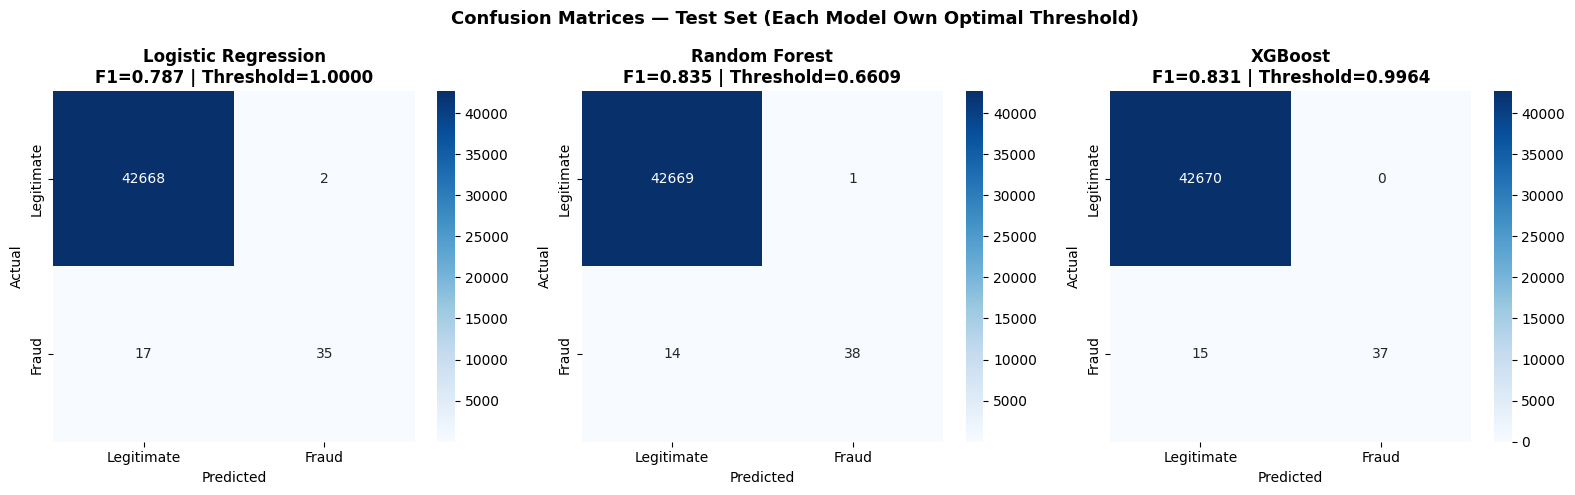

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_cm = {
    'Logistic Regression': lr.predict_proba(X_test_scaled)[:, 1],
    'Random Forest':       rf.predict_proba(X_test)[:, 1],
    'XGBoost':             xgb_model.predict_proba(X_test)[:, 1]
}

for i, (name, probs) in enumerate(models_cm.items()):
    f1, threshold, _, _ = find_best_f1_threshold(y_test, probs)
    preds = (probs >= threshold).astype(int)
    cm    = confusion_matrix(y_test, preds)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Legitimate', 'Fraud'],
                yticklabels=['Legitimate', 'Fraud'],
                ax=axes[i])
    
    axes[i].set_title(f'{name}\nF1={f1:.3f} | Threshold={threshold:.4f}',
                      fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Test Set (Each Model Own Optimal Threshold)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [59]:
# save evaluation results for production reference
import json

evaluation_results = {
    'dataset': {
        'total_transactions': 284807,
        'total_fraud': 492,
        'fraud_rate': 0.00173,
        'observation_window': '48 hours'
    },
    'splits': {
        'train': {'rows': 199364, 'fraud_rate': 0.00193},
        'validate': {'rows': 42721, 'fraud_rate': 0.00131},
        'test': {'rows': 42722, 'fraud_rate': 0.00122}
    },
    'champion_model': 'XGBoost',
    'champion_rationale': [
        'Best score calibration (mean=0.16% vs true rate 0.13%)',
        'Perfect precision at optimal threshold (zero false alarms)',
        'Most operationally viable at business cost threshold',
        'Expected to outperform with hyperparameter tuning'
    ],
    'test_set_performance': {
        'Logistic Regression': {
            'KS': 0.8568, 'AUPRC': 0.6965,
            'F1': 0.7865, 'Precision': 0.9459,
            'Recall': 0.6731, 'threshold': 1.0000
        },
        'Random Forest': {
            'KS': 0.8403, 'AUPRC': 0.7703,
            'F1': 0.8352, 'Precision': 0.9744,
            'Recall': 0.7308, 'threshold': 0.6609
        },
        'XGBoost': {
            'KS': 0.8258, 'AUPRC': 0.7632,
            'F1': 0.8315, 'Precision': 1.0000,
            'Recall': 0.7115, 'threshold': 0.9964
        }
    },
    'business_threshold': {
        'value': 0.0784,
        'cost_fn': 150,
        'cost_fp': 10,
        'estimated_cost': 1420,
        'recall_at_threshold': 0.875,
        'precision_at_threshold': 0.570
    },
    'concept_drift_evidence': {
        'hour_2_fraud_rate': 0.017,
        'hour_26_fraud_rate': 0.032,
        'drift_magnitude': '88% increase day over day'
    },
    'top_features': {
        'SHAP': ['V4', 'V14', 'V12', 'V10', 'V11'],
        'IV':   ['V14', 'V12', 'V17', 'V10', 'V4'],
        'XGB_gain': ['V14', 'V10', 'V4', 'V12', 'V20']
    },
    'production_recommendations': [
        'Retrain with TimeSeriesSplit hyperparameter tuning',
        'Implement per-customer velocity features via feature store',
        'Extend observation window to 12-24 months',
        'Monitor PSI weekly on top features',
        'Set KS alert threshold at 0.75 for retraining trigger'
    ]
}

with open('../models/evaluation_results.json', 'w') as f:
    json.dump(evaluation_results, f, indent=4)

print("Evaluation results saved ✅")

Evaluation results saved ✅
